In [1]:
import os
import urllib.request
import zipfile
from pathlib import Path
from PIL import Image
import rasterio as rio
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
from prettytable import PrettyTable

In [2]:
# Скачиваем датасет

url = "https://emapr.ceoas.oregonstate.edu/sparcs/sparcs_data_L8.zip"
file_path = "datasets/sparcs/sparcs_data_L8.zip"

if os.path.exists("datasets/sparcs/sparcs_data_L8.zip"):
    print("Файл уже скачан!")
else:
    urllib.request.urlretrieve(url, file_path)
    print("Файл загружен!")

Файл уже скачан!


In [3]:
# Распаковываем zip-архив

zip_path = "datasets/sparcs/sparcs_data_L8.zip"
extract_to = "datasets/sparcs/sparcs_data_L8"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("ZIP-архив успешно распакован!")

ZIP-архив успешно распакован!


In [5]:
# Добавляем нужные файлы

images_all_bands = []
masks = []

folder_path = Path("./datasets/sparcs/sparcs_data_L8")

for image_file in tqdm(folder_path.glob('*_data.tif'), "Загрузка элементов датасет в память"):
    prefix = image_file.stem.replace('_data', '')
    mask_file = folder_path / f'{prefix}_labels.tif'

    if mask_file.exists():
        with rio.open(image_file) as src, rio.open(mask_file) as dst:
            image = src.read()
            images_all_bands.append(image)
            mask = dst.read()
            masks.append(mask)

images_all_bands = np.array(images_all_bands)
masks = np.array(masks)
        

Загрузка элементов датасет в память: 78it [00:04, 18.28it/s]


### Общая информация

In [6]:
print(f"Количество элементов датасета: {len(images_all_bands)}")

Количество элементов датасета: 78


In [7]:
print(f"Параметры изображения: {images_all_bands[0].shape}")
print(f"Параметры маски: {masks[0].shape}")
print("Представлены 10 каналов и истинная маска")

Параметры изображения: (10, 1000, 1000)
Параметры маски: (1, 1000, 1000)
Представлены 10 каналов и истинная маска


In [8]:
print("Маска представлена 7 значениями:")

masks_content = PrettyTable()

masks_content.field_names = ["Mask Code", "Feature"]

masks_content.add_row([0, "Cloud Shadow"])
masks_content.add_row([1, "Cloud Shadow over Water"])
masks_content.add_row([2, "Water"])
masks_content.add_row([3, "Ice/Snow"])
masks_content.add_row([4, "Land"])
masks_content.add_row([5, "Clouds"])
masks_content.add_row([6, "Flooded"])

print(masks_content)

Маска представлена 7 значениями:
+-----------+-------------------------+
| Mask Code |         Feature         |
+-----------+-------------------------+
|     0     |       Cloud Shadow      |
|     1     | Cloud Shadow over Water |
|     2     |          Water          |
|     3     |         Ice/Snow        |
|     4     |           Land          |
|     5     |          Clouds         |
|     6     |         Flooded         |
+-----------+-------------------------+


In [9]:
# Отберем только нужные каналы: R, G, B, NIR

images = []

for image in images_all_bands:
    images.append(np.stack([image[3], image[2], image[1], image[4]]))
    
images = np.array(images)

### Визуализация

In [10]:
def visualize(r, g, b, nir, mask):
    
    plt.figure(figsize=(30, 7))

    plt.subplot(1, 5, 1)
    plt.imshow(r, cmap='Reds')
    plt.title("Red band image")
    plt.axis("off")

    plt.subplot(1, 5, 2)
    plt.imshow(g, cmap='Greens')
    plt.title("Green band image")
    plt.axis("off")

    plt.subplot(1, 5, 3)
    plt.imshow(b, cmap='Blues')
    plt.title("Blue band image")
    plt.axis("off")

    plt.subplot(1, 5, 4)
    plt.imshow(nir, cmap='plasma')
    plt.title("NIR band image")
    plt.axis("off")

    plt.subplot(1, 5, 5)
    plt.imshow(mask, cmap='gray')
    plt.title("Original mask")
    plt.axis("off")

    plt.show()

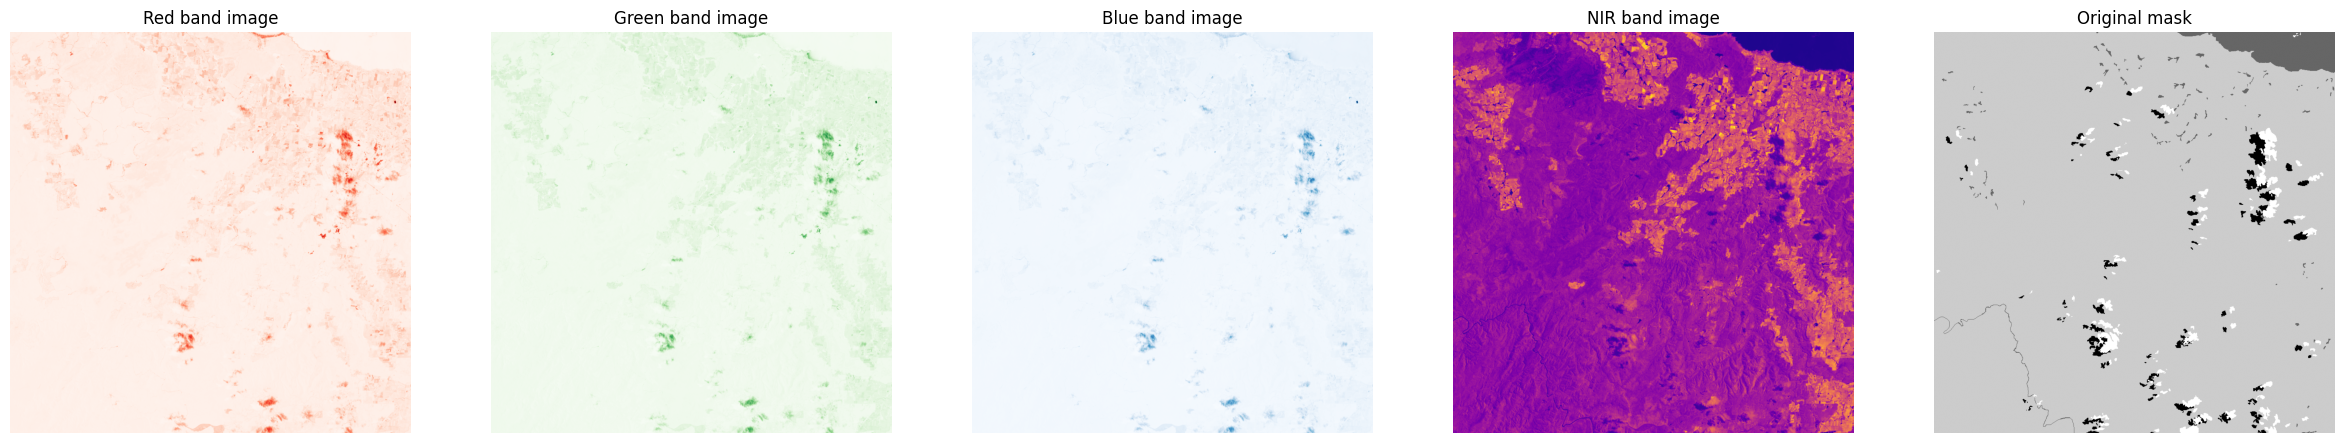

In [11]:
# Пример элемента датасета
image = images[0]
mask = masks[0]
visualize(image[0], image[1], image[2], image[3], mask.squeeze())

### Анализ изображений

In [12]:
# Проверка на пустые изображения
null_count = 0
for image in images:
    if image.max() == 0:
        null_count += 1

null_masks_perc = round(null_count/len(images)*100, 2)
        
print(f"{null_count}/{len(images)} ({null_masks_perc}%) пустых изображений")

0/78 (0.0%) пустых изображений


In [13]:
# Проверка, какая площадь занята ненулевыми пикселями на непустых изображениях
occupancy = []
for image in images:
    rgbi = image[:4]
    nonzero_mask = np.any(rgbi != 0, axis=-1)
    occupied_pixels = np.sum(nonzero_mask)
    total_pixels = rgbi.shape[0] * rgbi.shape[1]
    fraction = occupied_pixels / total_pixels
    occupancy.append(fraction)

occupancy_perc = round(np.mean(occupancy) * 100, 2)

print(f'{occupancy_perc}% - средняя занятость изображения ненулевыми пикселями на непустых изображениях')

100.0% - средняя занятость изображения ненулевыми пикселями на непустых изображениях


(np.float64(-0.5), np.float64(999.5), np.float64(999.5), np.float64(-0.5))

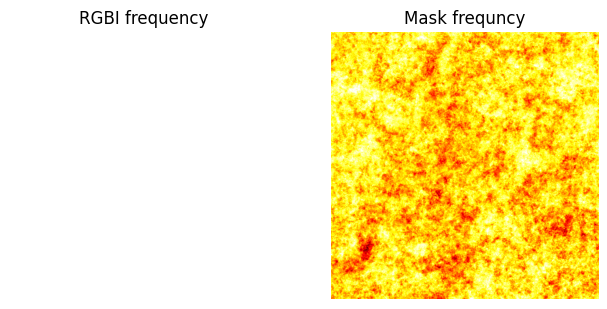

In [14]:
# Смотрим, где сосредоточены основные пиксели
pixel_location_rgbi = np.zeros_like(images[0][0])
pixel_location_gt = np.zeros_like(masks[0][0])
for image in images:
    pixel_location_rgbi += (image[0] != 0) + (image[1] != 0) + (image[2] != 0) + (image[3] != 0)
    
for mask in masks:
    pixel_location_gt += (mask.squeeze() != 0)

plt.figure(figsize=(20, 10))

plt.subplot(1, 5, 1)
plt.imshow(pixel_location_rgbi, cmap='hot', vmin=0, vmax=pixel_location_rgbi.max())
plt.title("RGBI frequency")
plt.axis("off")

plt.subplot(1, 5, 2)
plt.imshow(pixel_location_gt, cmap='hot')
plt.title("Mask frequncy")
plt.axis("off")

In [15]:
# Посчитаем среднее содержание целевых классов на снимках

features_massive = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

for mask in masks:
    features_massive[0] += np.sum(mask.squeeze() == 0)/(mask.shape[1] * mask.shape[2])
    features_massive[1] += np.sum(mask.squeeze() == 1)/(mask.shape[1] * mask.shape[2])
    features_massive[2] += np.sum(mask.squeeze() == 2)/(mask.shape[1] * mask.shape[2])
    features_massive[3] += np.sum(mask.squeeze() == 3)/(mask.shape[1] * mask.shape[2])
    features_massive[4] += np.sum(mask.squeeze() == 4)/(mask.shape[1] * mask.shape[2])
    features_massive[5] += np.sum(mask.squeeze() == 5)/(mask.shape[1] * mask.shape[2])
    features_massive[6] += np.sum(mask.squeeze() == 6)/(mask.shape[1] * mask.shape[2])

    
features_massive /= len(masks)

print("Содержание целевых классов на снимках:")

masks_content_perc = PrettyTable()

masks_content_perc.field_names = ["Feature", "Perc(%) of content"]

masks_content_perc.add_row(["Cloud Shadow", f"{round(features_massive[0]*100, 2)}%"])
masks_content_perc.add_row(["Cloud Shadow over Water", f"{round(features_massive[1]*100, 2)}%"])
masks_content_perc.add_row(["Water", f"{round(features_massive[2]*100, 2)}%"])
masks_content_perc.add_row(["Ice/Snow", f"{round(features_massive[3]*100, 2)}%"])
masks_content_perc.add_row(["Land", f"{round(features_massive[4]*100, 2)}%"])
masks_content_perc.add_row(["Clouds", f"{round(features_massive[5]*100, 2)}%"])
masks_content_perc.add_row(["Flooded", f"{round(features_massive[6]*100, 2)}%"])

print(masks_content_perc)

Содержание целевых классов на снимках:
+-------------------------+--------------------+
|         Feature         | Perc(%) of content |
+-------------------------+--------------------+
|       Cloud Shadow      |       7.16%        |
| Cloud Shadow over Water |       0.26%        |
|          Water          |       6.64%        |
|         Ice/Snow        |       5.44%        |
|           Land          |       60.99%       |
|          Clouds         |       19.51%       |
|         Flooded         |        0.0%        |
+-------------------------+--------------------+


In [19]:
# Mean и std для изображений
means = []
stds = []

for image in images:
    means.append(image.mean(axis=(1,2)))
    stds.append(image.std(axis=(1,2)))

means = np.array(means)
stds = np.array(stds)

means = means.mean(axis=0)
stds = stds.mean(axis=0)

images_means_stds = PrettyTable()

images_means_stds.field_names = ["Band", "Mean", "Std"]

images_means_stds.add_row(["R", round(means[0], 2), round(stds[0], 2)])
images_means_stds.add_row(["G", round(means[1], 2), round(stds[1], 2)])
images_means_stds.add_row(["B", round(means[2], 2), round(stds[2], 2)])
images_means_stds.add_row(["NIR", round(means[3], 2), round(stds[3], 2)])

print(images_means_stds)

+------+----------+---------+
| Band |   Mean   |   Std   |
+------+----------+---------+
|  R   | 12504.86 | 4670.25 |
|  G   | 12369.86 | 4267.42 |
|  B   | 12807.84 | 4186.79 |
| NIR  | 16794.15 | 5021.88 |
+------+----------+---------+


(4, 1000, 1000)


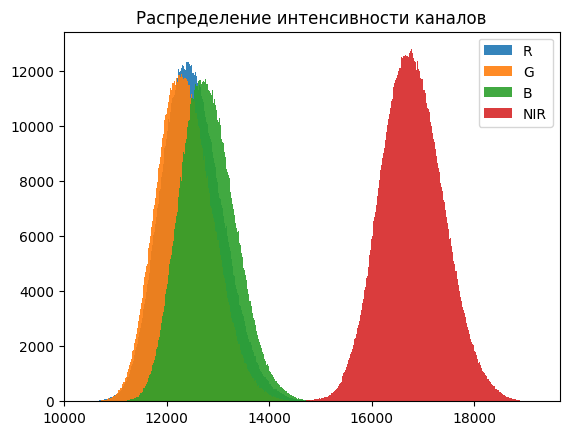

In [20]:
# Гистограмма распределения цветов для каждого канала (R, G, B, NIR)

images_average = np.mean(images, axis=0)
print(images_average.shape)

for i, col in enumerate(['R', 'G', 'B', 'NIR']):
    plt.hist(images_average[i, ...].ravel(), bins=256, alpha=0.9, label=col)
plt.legend(); plt.title("Распределение интенсивности каналов")
plt.show()

### Итог

In [21]:
# Итоговый отчет

df = pd.DataFrame({
    'Метрика': ['Всего изображений', 'Формат изображений', 'Размер изображения', 'Средняя доля облаков', 'Пустых масок', 'Тип масок'],
    'Значение': [len(images), 'TIF', images.shape[2:4], f"{round(features_massive[5]*100, 2)}%", f'{null_masks_perc}%', '7 классов']
})

df

,Метрика,Значение
0,Всего изображений,78
1,Формат изображений,TIF
2,Размер изображения,"(1000, 1000)"
3,Средняя доля облаков,19.51%
4,Пустых масок,0.0%
5,Тип масок,7 классов
